Using device: cpu

--- Starting Training ---
Epoch    1/2000 | Loss: 3.037213e-02
Epoch  200/2000 | Loss: 1.576714e-02
Epoch  400/2000 | Loss: 1.159695e-03
Epoch  600/2000 | Loss: 1.680876e-04
Epoch  800/2000 | Loss: 8.678996e-05
Epoch 1000/2000 | Loss: 6.359891e-05
Epoch 1200/2000 | Loss: 5.015734e-05
Epoch 1400/2000 | Loss: 4.065739e-05
Epoch 1600/2000 | Loss: 3.398846e-05
Epoch 1800/2000 | Loss: 3.101712e-05
Epoch 2000/2000 | Loss: 3.089609e-05
--- Training Complete ---



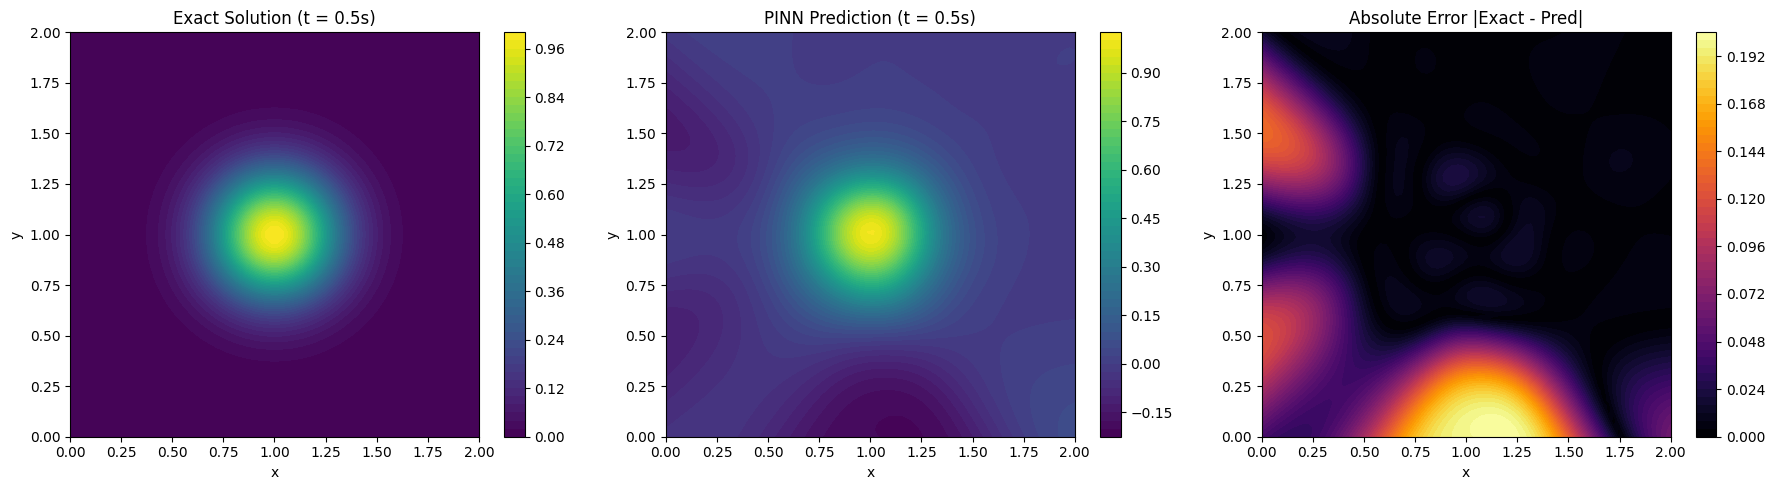

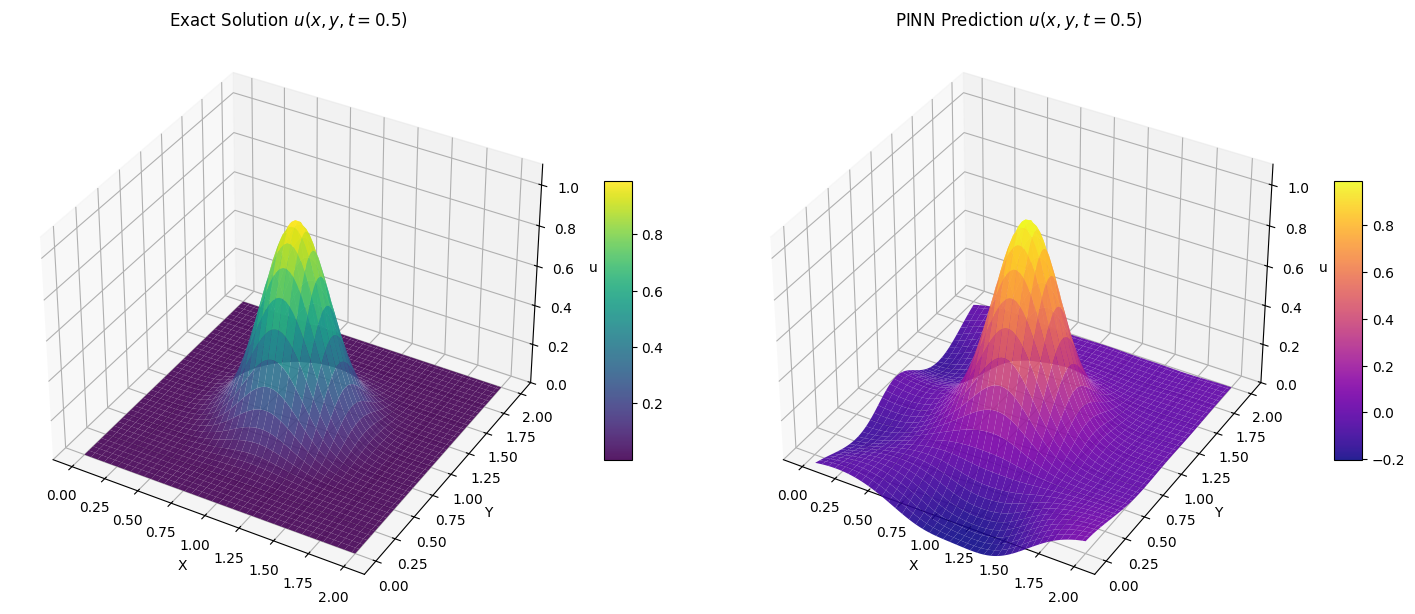

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Device Setup & Seeds
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 2. PINN Neural Network Architecture
# ==========================================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        a = inputs
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        return self.linears[-1](a)

# ==========================================
# 3. Solver & Physics Loss Formulation
# ==========================================
class LinearConvectionPINN2D:
    def __init__(self, cx=1.0, cy=1.0):
        self.cx = cx
        self.cy = cy

        # Neural Network: 3 inputs (x, y, t) -> Hidden Layers -> 1 output (u)
        self.dnn = PINN([3, 64, 64, 64, 1]).to(device)
        self.optimizer = torch.optim.Adam(self.dnn.parameters(), lr=1e-3)

    def net_u(self, x, y, t):
        return self.dnn(x, y, t)

    def net_f(self, x, y, t):
        """Compute residual: du/dt + cx * du/dx + cy * du/dy = 0"""
        u = self.net_u(x, y, t)

        # Reverse-mode automatic differentiation
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]

        f = u_t + self.cx * u_x + self.cy * u_y
        return f

    def loss_fn(self, x_ic, y_ic, t_ic, u_ic, x_f, y_f, t_f):
        # Initial Condition Loss
        u_pred_ic = self.net_u(x_ic, y_ic, t_ic)
        loss_ic = torch.mean((u_pred_ic - u_ic) ** 2)

        # PDE Collocation Residual Loss
        f_pred = self.net_f(x_f, y_f, t_f)
        loss_f = torch.mean(f_pred ** 2)

        return loss_ic + loss_f

    def train(self, epochs, x_ic, y_ic, t_ic, u_ic, x_f, y_f, t_f):
        for epoch in range(1, epochs + 1):
            self.optimizer.zero_grad()
            loss = self.loss_fn(x_ic, y_ic, t_ic, u_ic, x_f, y_f, t_f)
            loss.backward()
            self.optimizer.step()

            if epoch % 200 == 0 or epoch == 1:
                print(f"Epoch {epoch:4d}/{epochs} | Loss: {loss.item():.6e}")

# ==========================================
# 4. Training Data Generation
# ==========================================
cx, cy = 1.0, 1.0
model = LinearConvectionPINN2D(cx=cx, cy=cy)

# Generate Initial Condition points (t = 0)
N_ic = 1000
x_ic_np = np.random.uniform(0.0, 2.0, (N_ic, 1))
y_ic_np = np.random.uniform(0.0, 2.0, (N_ic, 1))
t_ic_np = np.zeros_like(x_ic_np)

# Initial smooth Gaussian profile centered at (0.5, 0.5)
u_ic_np = np.exp(-((x_ic_np - 0.5)**2 + (y_ic_np - 0.5)**2) / 0.1)

# Generate PDE Collocation points across domain and time t in [0, 0.5]
N_f = 10000
x_f_np = np.random.uniform(0.0, 2.0, (N_f, 1))
y_f_np = np.random.uniform(0.0, 2.0, (N_f, 1))
t_f_np = np.random.uniform(0.0, 0.5, (N_f, 1))

# Convert to PyTorch tensors
x_ic = torch.tensor(x_ic_np, dtype=torch.float32, device=device)
y_ic = torch.tensor(y_ic_np, dtype=torch.float32, device=device)
t_ic = torch.tensor(t_ic_np, dtype=torch.float32, device=device)
u_ic = torch.tensor(u_ic_np, dtype=torch.float32, device=device)

x_f = torch.tensor(x_f_np, dtype=torch.float32, device=device, requires_grad=True)
y_f = torch.tensor(y_f_np, dtype=torch.float32, device=device, requires_grad=True)
t_f = torch.tensor(t_f_np, dtype=torch.float32, device=device, requires_grad=True)

# Train the model
print("\n--- Starting Training ---")
model.train(epochs=2000, x_ic=x_ic, y_ic=y_ic, t_ic=t_ic, u_ic=u_ic, x_f=x_f, y_f=y_f, t_f=t_f)
print("--- Training Complete ---\n")

# ==========================================
# 5. Prediction & Post-Processing
# ==========================================
nx, ny = 80, 80
x_val = np.linspace(0.0, 2.0, nx)
y_val = np.linspace(0.0, 2.0, ny)
X, Y = np.meshgrid(x_val, y_val)

t_snapshot = 0.5
T = np.full_like(X, t_snapshot)

# Flatten for neural network evaluation
x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device)
y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device)
t_flat = torch.tensor(T.flatten()[:, None], dtype=torch.float32, device=device)

model.dnn.eval()
with torch.no_grad():
    u_pred = model.net_u(x_flat, y_flat, t_flat).cpu().numpy().reshape(ny, nx)

# Analytical solution at t_snapshot
x_shifted = X - cx * t_snapshot
y_shifted = Y - cy * t_snapshot
u_exact = np.exp(-((x_shifted - 0.5)**2 + (y_shifted - 0.5)**2) / 0.1)
abs_error = np.abs(u_exact - u_pred)

# ==========================================
# 6. Plotting: 2D Contours
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].contourf(X, Y, u_exact, levels=50, cmap='viridis')
axes[0].set_title(f"Exact Solution (t = {t_snapshot}s)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, Y, u_pred, levels=50, cmap='viridis')
axes[1].set_title(f"PINN Prediction (t = {t_snapshot}s)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X, Y, abs_error, levels=50, cmap='inferno')
axes[2].set_title(f"Absolute Error |Exact - Pred|")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# ==========================================
# 7. Plotting: 3D Surface Plots
# ==========================================
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, u_exact, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title(f'Exact Solution $u(x, y, t={t_snapshot})$', pad=12)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('u')
ax1.set_zlim(0, 1.1)
ax1.view_init(elev=35, azim=-60)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, u_pred, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_title(f'PINN Prediction $u(x, y, t={t_snapshot})$', pad=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('u')
ax2.set_zlim(0, 1.1)
ax2.view_init(elev=35, azim=-60)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 8. FDM (Finite Difference) Solution for Comparison
# ==========================================
# Same PDE, IC, cx/cy, grid (X, Y) and snapshot time as the PINN run above,
# solved with a first-order upwind finite-difference scheme.

dx = x_val[1] - x_val[0]
dy = y_val[1] - y_val[0]

cfl = 0.4
dt_fdm = cfl * min(dx, dy) / max(cx, cy)
nt_fdm = int(np.ceil(t_snapshot / dt_fdm))
dt_fdm = t_snapshot / nt_fdm  # land exactly on t_snapshot

u_fdm = np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1)  # same Gaussian IC

for _ in range(nt_fdm):
    un = u_fdm.copy()
    u_fdm[1:, 1:] = (un[1:, 1:]
                     - cx * dt_fdm / dx * (un[1:, 1:] - un[1:, :-1])
                     - cy * dt_fdm / dy * (un[1:, 1:] - un[:-1, 1:]))
    u_fdm[0, :] = 0.0
    u_fdm[:, 0] = 0.0

fdm_rms_err = np.sqrt(np.mean((u_fdm - u_exact) ** 2))
pinn_rms_err = np.sqrt(np.mean((u_pred - u_exact) ** 2))
print(f"FDM RMS error vs exact:  {fdm_rms_err:.5f}  ({nt_fdm} steps, dt={dt_fdm:.4f})")
print(f"PINN RMS error vs exact: {pinn_rms_err:.5f}")

# ==========================================
# 9. Plotting: FDM vs PINN, side by side
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

im0 = axes[0].contourf(X, Y, u_fdm, levels=50, cmap='viridis')
axes[0].set_title(f"FDM (upwind) Solution (t = {t_snapshot}s)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect('equal')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].contourf(X, Y, u_pred, levels=50, cmap='viridis')
axes[1].set_title(f"PINN Prediction (t = {t_snapshot}s)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect('equal')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("2-D Linear Convection: FDM vs PINN", fontsize=14)
plt.tight_layout()
plt.show()
